# GZD-5 Classfication
___

## Setup

### Importing Packages

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from umap import UMAP
from projectFunctions import feature_pre_processing, label_pre_processing, myBGMM, myMBKM, distance_bin_plots, add_thumbnail_panel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.patches import ConnectionPatch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import Rectangle
import seaborn as sns

colors = list(plt.cm.tab20.colors)
# Replace the grey colour
colors[15] = "#CF943A"
cmap_cluster = mcolors.ListedColormap(colors)

### Directories

In [2]:
# Data Root Directory
data_root_dir = os.path.join(os.getcwd(), 'Data')

# Image Directory
img_dir = os.path.join(data_root_dir, 'Images')

# Label Directory
#label_dir = os.path.join(data_root_dir, 'gz_decals_volunteers_5.parquet')
#full_volunteer_labels = pd.read_parquet(label_dir)
#volunteer_labels = label_pre_processing(full_volunteer_labels, data_root_dir, img_dir)

# Refined Volunteer Labels Directory
refined_label_dir = os.path.join(data_root_dir, 'volunteer_labels.parquet')
volunteer_labels = pd.read_parquet(refined_label_dir)
print('Labelled Galaxies: ', volunteer_labels.shape)
print('Round Ellipticals: ',    (volunteer_labels['Volunteer_Label'] == 'R').sum())
print('Spirals: ',              (volunteer_labels['Volunteer_Label'] == 'S').sum())
print('Edge-ons: ',             (volunteer_labels['Volunteer_Label'] == 'E').sum())

# Feature Directory
#feature_dir = os.path.join(data_root_dir, 'GalaxyZoo_Main_Features.parquet')
#features = pd.read_parquet(feature_dir)
#pca_features = feature_pre_processing(features, data_root_dir)

# PCA Feature Directory
pca_feature_dir = os.path.join(data_root_dir, 'pca_features.parquet')
pca_features = pd.read_parquet(pca_feature_dir)
print(f'PCA features: {pca_features.shape}')    

Labelled Galaxies:  (24858, 127)
Round Ellipticals:  9464
Spirals:  12432
Edge-ons:  2962
PCA features: (230575, 29)


## Clustering

In [3]:
method = 'MBKM'

# Output Directory
output_dir = os.path.join(os.getcwd(), f'{method}_Results')

no_of_runs = 1
rng = np.random.default_rng(41)

#no_of_clusters_to_test = np.arange(10,101,1)
no_of_clusters_to_test = np.array([20])

In [11]:
results = {} # Dictionary to store the results
# Siloutte and David Bouldin scores are calculated on a random sample of 10 000 galaxies to reduce computation time
metric_sample = rng.choice(len(pca_features), size=10000, replace=False)
# Save results after every completed run
temp_file = f"{method}_results_temp.pkl"
final_file = f"{method}_results.pkl"

for no_of_clusters in no_of_clusters_to_test:
    print(f"No. of Clusters: {no_of_clusters}")
    for run in range(no_of_runs):
        print(f'## Run {run + 1} ##')

        # CLUSTERING
        ########################

        if method == 'MBKM':
            mbkm_inertia, silhouette, david, clusters = myMBKM(pca_features, n_clusters=no_of_clusters, max_iter=10, n_init=10, 
                                                               metric_sample=metric_sample)
            prefix = 'Distance'
        elif method == 'BGMM':
            bgmm_weights, bgmm_lower_bound, silhouette, david, clusters = myBGMM(pca_features, n_components=no_of_clusters, weight_concentration_prior=0.5, 
                                                                                 n_init=10, max_iter=1000, metric_sample=metric_sample)
            prefix = 'Prob'

        # DATAFRAME MANIPULATION
        ########################

        # Finding the distance/probability columns in the clusters dataframe
        distance_cols = [f"{prefix}_{i}" for i in range(no_of_clusters)] 
        distance_array = clusters[distance_cols].to_numpy()
        # Finding Assigned Distance by selecting the distance corresponding to the assigned cluster for each row
        clusters[f'Assigned_{prefix}'] = distance_array[np.arange(len(clusters)), clusters['Cluster'].to_numpy()]
        
        # Filtering 'test_subset' to only include galaxies that have both a volunteer label and a cluster assignment
        test_subset = clusters.merge(volunteer_labels, left_index=True, right_index=True, how='inner')

        # Group 'test_subset' by 'Cluster' and 'Volunteer_Label' and count the number of galaxies in each group
        counts_df = test_subset.groupby(['Cluster', 'Volunteer_Label']).size().reset_index(name='Count')
        # Add Total and Percentage Accuracy Columns
        counts_df['Total'] = counts_df.groupby('Cluster')['Count'].transform('sum')
        counts_df['Percentage'] = counts_df['Count'] / counts_df['Total'] * 100
        print(counts_df)

        # Group 'counts_df' by 'Cluster' and find the row with the maximum 'Count' for each cluster
        dominant = counts_df.loc[counts_df.groupby('Cluster')['Count'].idxmax()]
        # Save Summary Array
        summary_df = dominant.set_index('Cluster')[['Volunteer_Label', 'Percentage']]
        summary_df.columns = ['Dominant_Type', 'Percentage']
        print(summary_df)

        # Map the dominant type to each galaxy based on its cluster assignment
        clusters["Dominant_Type"] = clusters["Cluster"].map(summary_df["Dominant_Type"])
        test_subset['Predicted_Label'] = test_subset['Cluster'].map(summary_df['Dominant_Type'])

        # EVALUATION METRICS
        ########################
        # Overall run accuracy
        run_accuracy = accuracy_score(test_subset['Volunteer_Label'], test_subset['Predicted_Label'])
        
        # Individual cluster accuracies 
        cluster_accuracies = {}
        for cluster in range(no_of_clusters):
            # Filter 'test_subset' to only the indivual cluster galaxies
            cluster_data = test_subset[test_subset["Cluster"] == cluster]
             
            # If no galaxies exist in a cluster, skip the accuracy calculation and return a NaN
            if len(cluster_data) == 0:
                cluster_accuracies[cluster] = np.nan
                print(f"{cluster}: No galaxies")
                continue
            accuracy = accuracy_score(cluster_data["Volunteer_Label"], cluster_data["Predicted_Label"])
            cluster_accuracies[cluster] = accuracy

        if no_of_clusters not in results:
            results[no_of_clusters] = {}

        if method == 'MBKM':
            results[no_of_clusters][run + 1] = {
                "accuracy": run_accuracy,
                "inertia": mbkm_inertia,
                "silhouette": silhouette,
                "david_bouldin": david,
                "cluster_accuracies": cluster_accuracies,
                "test_subset_data": test_subset.copy()
            }

        elif method == 'BGMM':
            results[no_of_clusters][run + 1] = {
                "accuracy": run_accuracy,
                "weights": bgmm_weights,
                "silhouette": silhouette,
                "lower_bound": bgmm_lower_bound,
                "david_bouldin": david,
                "cluster_accuracies": cluster_accuracies,
                "test_subset_data": test_subset.copy()
            }

        with open(temp_file, "wb") as f:
            pickle.dump(results, f)
        os.replace(temp_file, final_file)

        print(f"Saved: {no_of_clusters} clusters, run {run + 1}")

        print('Classification Report\n#####################')
        print(classification_report(test_subset['Volunteer_Label'], test_subset['Predicted_Label'], labels=['R', 'S', 'E']))

clusters.to_parquet(os.path.join(output_dir, f'{method}_clusters'))

No. of Clusters: 20
## Run 1 ##
    Cluster Volunteer_Label  Count  Total  Percentage
0         0               E      7    722    0.969529
1         0               R    105    722   14.542936
2         0               S    610    722   84.487535
3         1               E     18    921    1.954397
4         1               R    743    921   80.673181
5         1               S    160    921   17.372421
6         2               E    625   1155   54.112554
7         2               R      2   1155    0.173160
8         2               S    528   1155   45.714286
9         3               E      3   2043    0.146843
10        3               R    240   2043   11.747430
11        3               S   1800   2043   88.105727
12        4               E      5     45   11.111111
13        4               R     22     45   48.888889
14        4               S     18     45   40.000000
15        5               E     10     95   10.526316
16        5               R     47     95   49.473

In [12]:
cluster_count = clusters.groupby(['Cluster', 'Dominant_Type']).size()
print(cluster_count)

Cluster  Dominant_Type
0        S                17920
1        R                 9212
2        E                10617
3        S                17275
4        R                 1282
5        R                 1950
6        S                 5639
7        S                17771
8        S                18774
9        R                13195
10       S                14200
11       E                14264
12       S                20490
13       R                14390
14       R                16015
15       S                 5825
16       R                 1166
17       R                  307
18       R                20594
19       R                 9689
dtype: int64


In [13]:
print('Class Accuracy\n##############')
R_accuracy = accuracy_score(test_subset[test_subset['Volunteer_Label'] == 'R']['Volunteer_Label'], test_subset[test_subset['Volunteer_Label'] == 'R']['Predicted_Label']) 
S_accuracy = accuracy_score(test_subset[test_subset['Volunteer_Label'] == 'S']['Volunteer_Label'], test_subset[test_subset['Volunteer_Label'] == 'S']['Predicted_Label']) 
E_accuracy = accuracy_score(test_subset[test_subset['Volunteer_Label'] == 'E']['Volunteer_Label'], test_subset[test_subset['Volunteer_Label'] == 'E']['Predicted_Label']) 
print(f'R: {R_accuracy:.4f}')
print(f'S: {S_accuracy:.4f}')
print(f'E: {E_accuracy:.4f}')
accuracy = accuracy_score(test_subset['Volunteer_Label'], test_subset['Predicted_Label'])
print(accuracy)

Class Accuracy
##############
R: 0.8114
S: 0.7625
E: 0.6292
0.7670631639208702


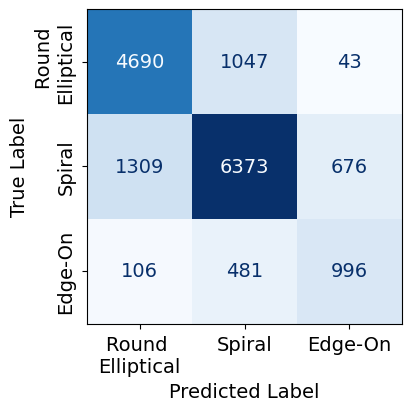

In [14]:
fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True)

cm = confusion_matrix(test_subset['Volunteer_Label'], test_subset['Predicted_Label'], labels=['R', 'S', 'E'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Round \nElliptical', 'Spiral', 'Edge-On'])
disp.plot(ax=ax, colorbar=False ,cmap=plt.cm.Blues)
for text in ax.texts:
    text.set_fontsize(14)

ax.tick_params(axis="y", labelsize=14, pad=5)
ax.tick_params(axis='x', labelsize=14, pad=5)
for label in ax.get_yticklabels():
    label.set_rotation(90)
    label.set_va("center")
    label.set
ax.set_xlabel("Predicted Label", fontsize=14)
ax.set_ylabel("True Label", fontsize=14)
plt.savefig(os.path.join(output_dir, f'{method}_CM.png'))
display(fig)
plt.close(fig)

In [15]:
print(results[20][1]['cluster_accuracies'])
high_acc = []
low_acc = []

for cluster, acc in results[20][1]['cluster_accuracies'].items():
    if acc >= 0.70:
        high_acc.append(cluster)
    else:
        low_acc.append(cluster)
        
print('High Accuracy Clusters (>=0.75):', high_acc)
print('Low Accuracy Clusters (<0.5):', low_acc)

{0: 0.8448753462603878, 1: 0.8067318132464713, 2: 0.5411255411255411, 3: 0.8810572687224669, 4: 0.4888888888888889, 5: 0.49473684210526314, 6: 0.8179419525065963, 7: 0.9722337339411521, 8: 0.5969802555168409, 9: 0.869120654396728, 10: 0.5628654970760234, 11: 0.6625, 12: 0.5647773279352226, 13: 0.6266968325791855, 14: 0.7112970711297071, 15: 0.42295081967213116, 16: 0.5483870967741935, 17: 0.5833333333333334, 18: 0.897160883280757, 19: 0.824}
High Accuracy Clusters (>=0.75): [0, 1, 3, 6, 7, 9, 14, 18, 19]
Low Accuracy Clusters (<0.5): [2, 4, 5, 8, 10, 11, 12, 13, 15, 16, 17]


## UMAP

In [16]:
umap = UMAP(n_components=2, random_state=20)
umap_features = umap.fit_transform(pca_features)

/home/kirsten-elliott/MSc_Project/my_proj_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Full Feature Space

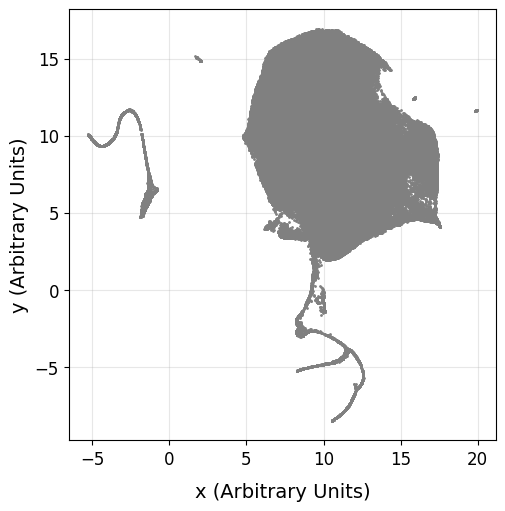

In [17]:
fig, ax = plt.subplots(figsize=(5,5), constrained_layout=True)

ax.set_aspect('equal')
ax.set_axisbelow(True) 
ax.grid(alpha=0.3)

ax.scatter(umap_features[:, 0], umap_features[:, 1], c='grey', s=1)

ax.set_xlabel('x (Arbitrary Units)', fontsize=14, labelpad=10)
ax.set_ylabel('y (Arbitrary Units)', fontsize=14)
ax.tick_params(labelsize=12)

plt.savefig(os.path.join(output_dir, 'UMAP_Full.png'))
display(fig)
plt.close(fig)

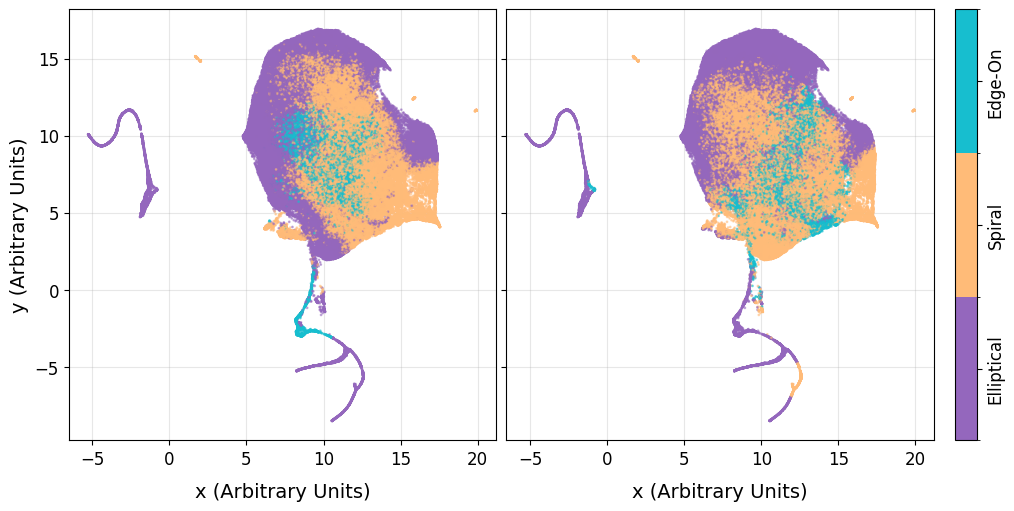

In [18]:
clusters_BGMM = pd.read_parquet('BGMM_Results/BGMM_clusters')
clusters_MBKM = pd.read_parquet('MBKM_Results/MBKM_clusters')

fig, ax = plt.subplots(1, 2, figsize=(10,5), sharey=True, constrained_layout=True)

ax[0].set_aspect('equal')
ax[0].set_axisbelow(True) 
ax[0].grid(alpha=0.3)
ax[1].set_aspect('equal')
ax[1].set_axisbelow(True) 
ax[1].grid(alpha=0.3)

# Coloured by Predicted Label
class_order = ['R', 'S', 'E']
class_to_int = {label: i for i, label in enumerate(class_order)}
type_colours = ["#9467bd", "#ffbb78", "#17becf"]
cmap_type = ListedColormap(type_colours)
norm_type = mcolors.BoundaryNorm(np.arange(-0.5, len(class_order) + 0.5, 1), cmap_type.N)
type_ints_BGMM = clusters_BGMM['Dominant_Type'].map(class_to_int)
type_ints_MBKM = clusters_MBKM['Dominant_Type'].map(class_to_int)

sc = ax[0].scatter(umap_features[:, 0], umap_features[:, 1], c=type_ints_BGMM, cmap=cmap_type, norm=norm_type, s=1, alpha=0.5, label='BGMM')
ax[1].scatter(umap_features[:, 0], umap_features[:, 1], c=type_ints_MBKM, cmap=cmap_type, norm=norm_type, s=1, alpha=0.5)

cbar = fig.colorbar(sc, ax=ax[1], ticks=np.arange(len(class_order)))
cbar.solids.set_alpha(1)
cbar.set_ticklabels(['Elliptical', 'Spiral', 'Edge-On'], rotation=90, va='center')
cbar.ax.tick_params(labelsize=12)

ax[0].set_xlabel("x (Arbitrary Units)",fontsize=14, labelpad=10)
ax[0].set_ylabel("y (Arbitrary Units)",fontsize=14)
ax[0].tick_params(labelsize=12)

ax[1].set_xlabel("x (Arbitrary Units)",fontsize=14, labelpad=10)
ax[1].tick_params(labelsize=12)

plt.savefig(os.path.join(output_dir, 'UMAP_classes.png'))
display(fig)
plt.close(fig)

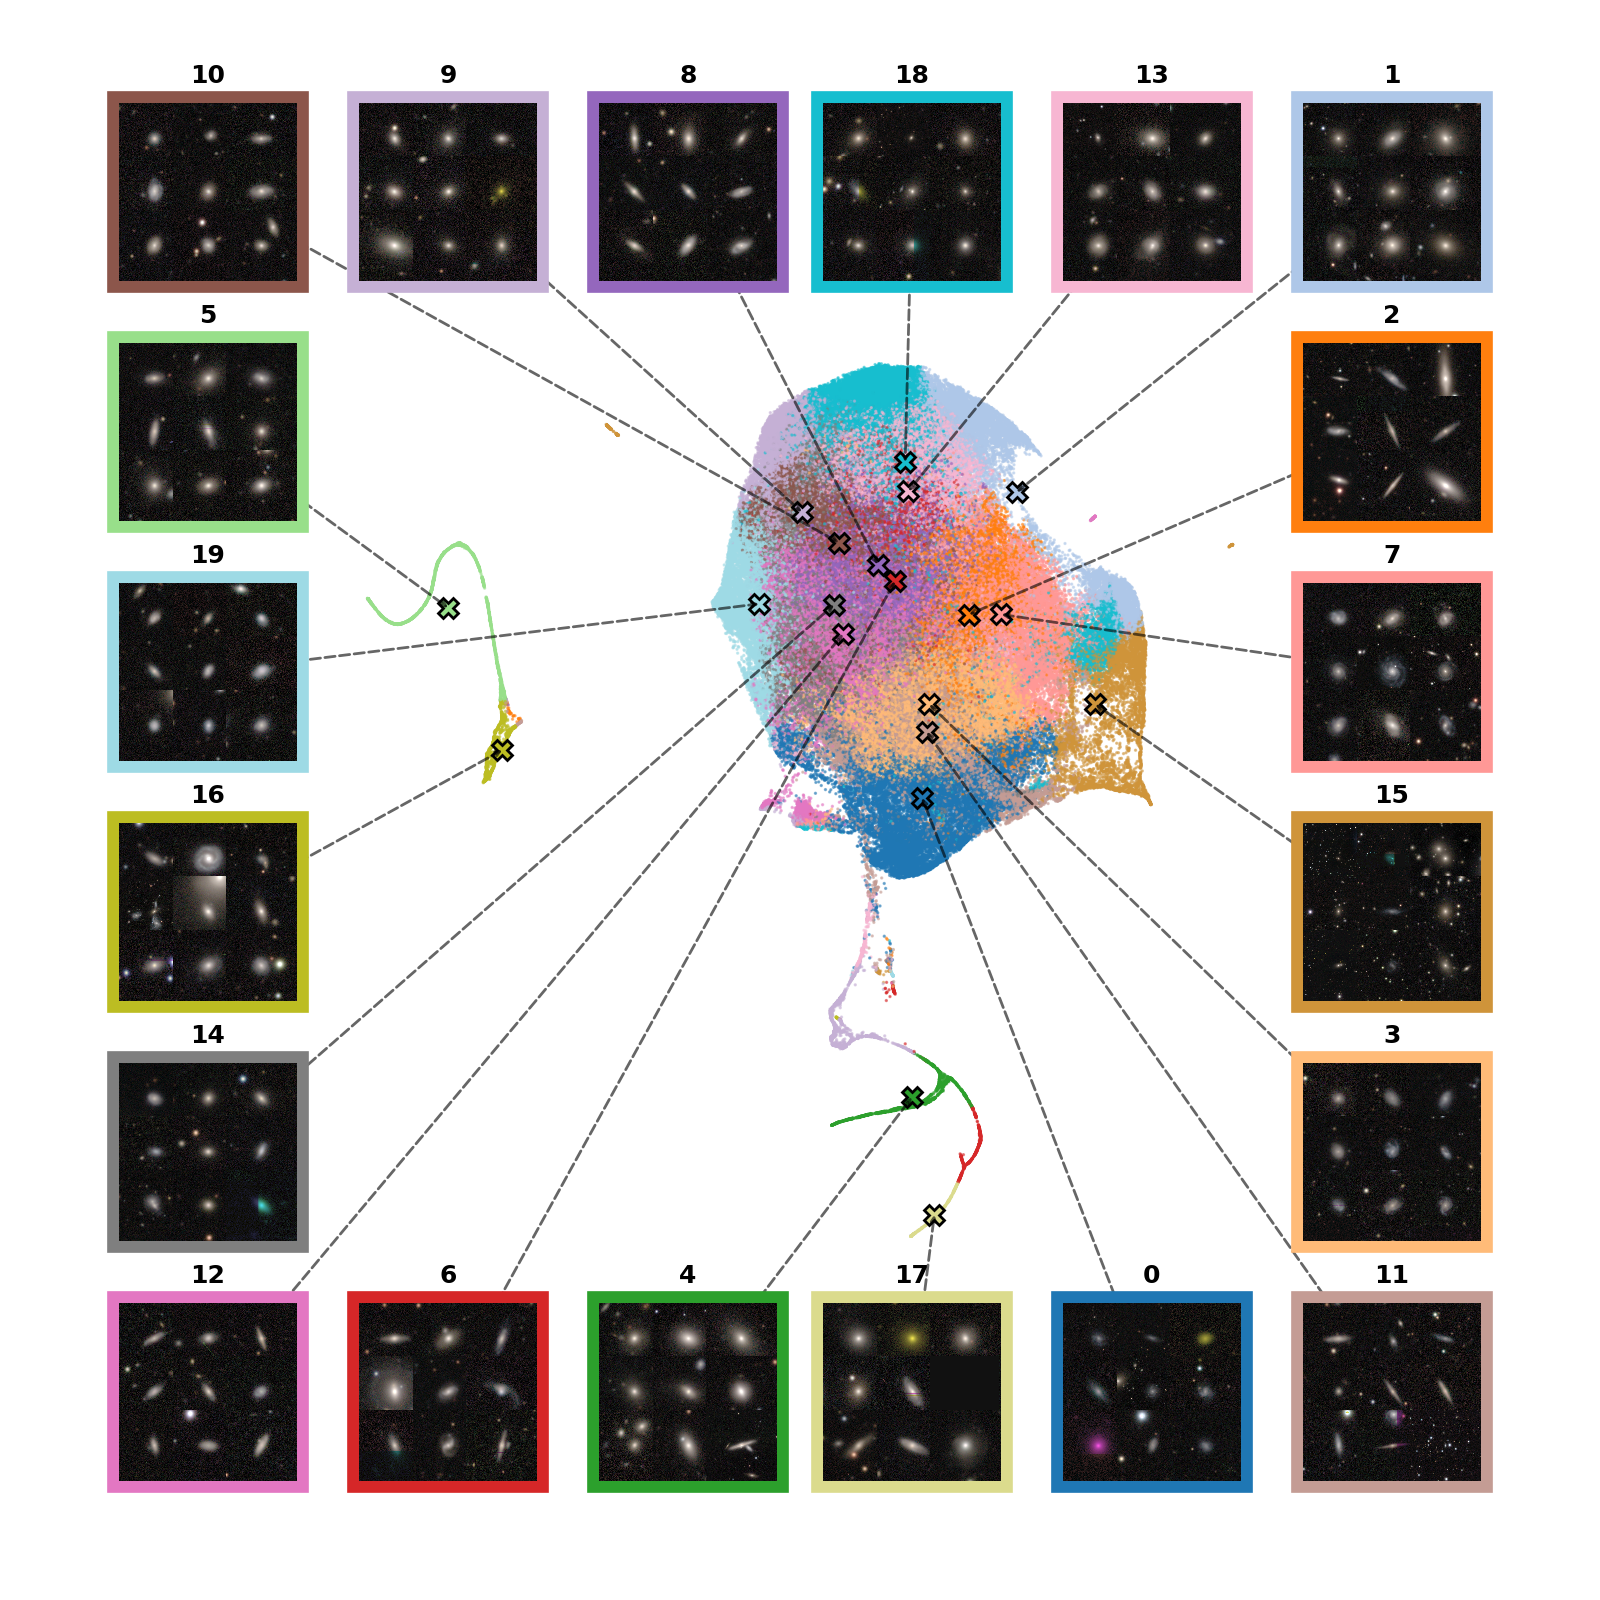

In [39]:
%matplotlib widget
from projectFunctions import add_thumbnail_panel

# FIND ALL IMAGE FILES
image_paths = {}
for root, dirs, files in os.walk(img_dir):
    for file in files:
        if file.endswith(".png"):
            image_id = os.path.splitext(file)[0]
            image_paths[image_id] = os.path.join(root, file)

# SELECT GALAXIES + FIND CENTRES
cluster_samples = {}
cluster_centres = {}
n_galaxies = 9

for cluster in sorted(clusters["Cluster"].unique()):
    # Galaxies belonging to this cluster
    cluster_data = clusters[clusters["Cluster"] == cluster]
    # Only galaxies with available images
    available = [idx
        for idx in cluster_data.index
        if str(idx) in image_paths]
    # Randomly select 9
    n_select = min(n_galaxies, len(available))
    selected = rng.choice(available, size=n_select, replace=False)
    cluster_samples[cluster] = selected
    # Find centre in UMAP space
    mask = clusters["Cluster"].values == cluster
    cluster_centres[cluster] = (np.mean(umap_features[mask, 0]), np.mean(umap_features[mask, 1]))

# INITIAL THUMBNAIL POSITIONS
width = 0.1
height = 0.1
thumbnail_positions = {
    12: [0.08, 0.08, width, height],
    14: [0.08, 0.23, width, height],
    16: [0.08, 0.38, width, height],
    19: [0.08, 0.53, width, height],
    5: [0.08, 0.68, width, height],
    10: [0.08, 0.83, width, height],
    9: [0.23, 0.83, width, height],
    8: [0.38, 0.83, width, height],
    18: [0.52, 0.83, width, height],
    13: [0.67, 0.83, width, height],
    1: [0.82, 0.83, width, height],
    2: [0.82, 0.68, width, height],
    7: [0.82, 0.53, width, height],
    15: [0.82, 0.38, width, height],
    3: [0.82, 0.23, width, height],
    11: [0.82, 0.08, width, height],
    0: [0.67, 0.08, width, height],
    17: [0.52, 0.08, width, height],
    4: [0.38, 0.08, width, height],
    6: [0.23, 0.08, width, height],
}

# CREATE MAIN UMAP
fig = plt.figure(figsize=(16, 16))
ax = fig.add_axes([0.2, 0.2, 0.6, 0.6])
clusters_integers = clusters["Cluster"].astype(int)
#cmap_cluster = plt.get_cmap("tab20", no_of_clusters)
norm_cluster = mcolors.BoundaryNorm(np.arange(-0.5, no_of_clusters + 0.5, 1), cmap_cluster.N)
sc_cluster = ax.scatter(umap_features[:, 0], umap_features[:, 1],
                c=clusters_integers, cmap=cmap_cluster, norm=norm_cluster,
                s=2, alpha=0.5)
ax.axis("off")
ax.set_aspect('equal')

# RED X AT CLUSTER CENTRES
for cluster, (x, y) in cluster_centres.items():
    cluster_color = cmap_cluster(norm_cluster(cluster))
    ax.plot(x, y, marker="X", markersize=15, markeredgewidth=2, color=cluster_color, markeredgecolor="black", label=label)

# CREATE THUMBNAILS
for cluster, selected_indices in cluster_samples.items():
    if cluster not in thumbnail_positions:
        continue
    # Same colour used by the UMAP
    cluster_color = cmap_cluster(norm_cluster(cluster))
    panel_ax = add_thumbnail_panel(fig=fig, selected_indices=selected_indices, cluster=cluster, position=thumbnail_positions[cluster], border_color=cluster_color, image_paths=image_paths)
    # Cluster centre
    cluster_x, cluster_y = cluster_centres[cluster]
    # Arrow from thumbnail to cluster centre
    arrow = ConnectionPatch(xyA=(0.5, 0.5), coordsA=panel_ax.transAxes,
                            xyB=(cluster_x, cluster_y), coordsB=ax.transData,
                            linestyle="--", arrowstyle="->", mutation_scale=8,
                            linewidth=2, alpha=0.6, zorder=1)
    fig.add_artist(arrow)

plt.savefig(os.path.join(output_dir, f'{method}_UMAP_clusters_thumbnails.png'))
plt.show()

/tmp/ipykernel_67397/616056944.py:44: UserWarning: Adding colorbar to a different Figure <Figure size 1600x1600 with 21 Axes> than <Figure size 1000x500 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(sc_cluster, ax=ax[1], ticks=np.arange(no_of_clusters))


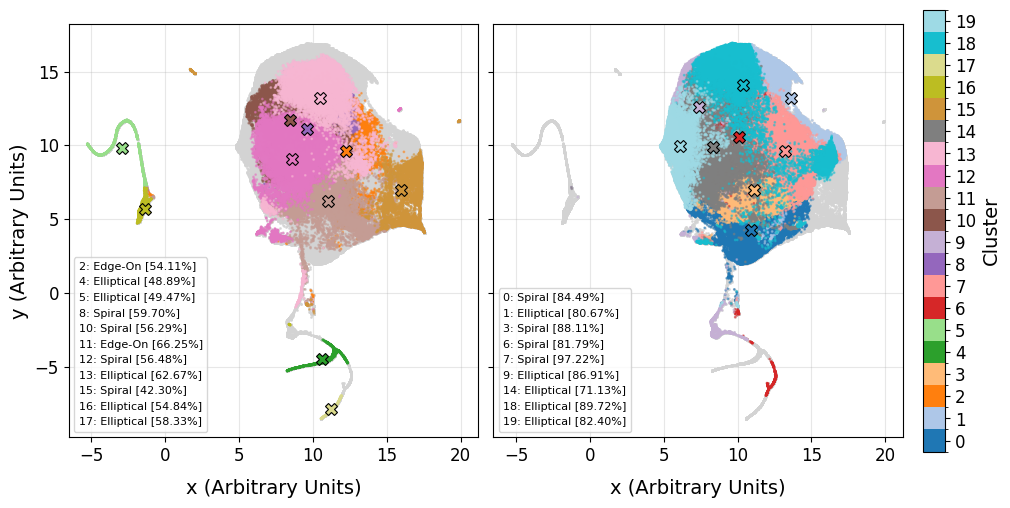

In [28]:
clusters_integers = clusters["Cluster"].astype(int)
full_counts = (clusters.groupby(['Cluster', 'Dominant_Type']).size().reset_index(name='Count'))
dominant_types = (full_counts.loc[full_counts.groupby('Cluster')['Count'].idxmax()].reset_index(drop=True))

def accuracy_plots(ax, acc_galaxies, cluster_int, dominant_types):
    # All galaxies in grey
    ax.scatter(umap_features[:, 0], umap_features[:, 1], c="lightgrey", s=1, alpha=0.8)
    # Selected clusters in colour
    for cluster in acc_galaxies:
        ax.set_aspect('equal')
        mask = cluster_int == cluster
        ax.scatter(umap_features[mask, 0], umap_features[mask, 1],
                        c=cluster_int[mask], cmap=cmap_cluster, norm=norm_cluster, s=1, alpha=0.5)

        # Cluster Centers
        x, y = cluster_centres[cluster]
        acc = cluster_accuracies[cluster]
        cluster_type = dominant_types.loc[dominant_types['Cluster'] == cluster, 'Dominant_Type'].iloc[0]
        if cluster_type == 'R':
            cluster_type = 'Elliptical'
        elif cluster_type == 'S':
            cluster_type = 'Spiral'
        elif cluster_type =='E':
            cluster_type = 'Edge-On'
        label = f'{cluster}: {cluster_type} [{(acc*100):.2f}%]'
        cluster_colour = cmap_cluster(norm_cluster(cluster))
        ax.plot(x, y, marker="X", markersize=8, markeredgewidth=0.8, color=cluster_colour, markeredgecolor="black", label=label)
        
    ax.set_xlabel("x (Arbitrary Units)", fontsize=14, labelpad=10)
    leg = ax.legend(handlelength=0, handletextpad=0, fontsize=8, loc='lower left')
    for item in leg.legend_handles:
        item.set_visible(False)

fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True, constrained_layout=True)

ax[0].set_axisbelow(True) 
ax[0].grid(alpha=0.3)
ax[1].set_axisbelow(True) 
ax[1].grid(alpha=0.3)

accuracy_plots(ax[0], low_acc, clusters_integers, dominant_types)
accuracy_plots(ax[1], high_acc, clusters_integers, dominant_types)

cbar = fig.colorbar(sc_cluster, ax=ax[1], ticks=np.arange(no_of_clusters))
cbar.solids.set_alpha(1)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Cluster", fontsize=14)

ax[0].set_ylabel("y (Arbitrary Units)", fontsize=14)
ax[0].tick_params(labelsize=12)
ax[1].tick_params(labelsize=12)

plt.savefig(os.path.join(output_dir, f'{method}_UMAP_acc.png'))
display(fig)
plt.close(fig)

### Test Set on Feature Space

In [29]:
print(clusters.columns.to_list())

test_subset = results[20][1]['test_subset_data']
print(test_subset.columns.to_list())

cluster_labels = test_subset[["Cluster", "Predicted_Label"]].drop_duplicates()
#print(cluster_labels)

#print(results[20][1]['cluster_accuracies'])

['Cluster', 'Center', 'Distance_0', 'Distance_1', 'Distance_2', 'Distance_3', 'Distance_4', 'Distance_5', 'Distance_6', 'Distance_7', 'Distance_8', 'Distance_9', 'Distance_10', 'Distance_11', 'Distance_12', 'Distance_13', 'Distance_14', 'Distance_15', 'Distance_16', 'Distance_17', 'Distance_18', 'Distance_19', 'Assigned_Distance', 'Dominant_Type']
['Cluster', 'Center', 'Distance_0', 'Distance_1', 'Distance_2', 'Distance_3', 'Distance_4', 'Distance_5', 'Distance_6', 'Distance_7', 'Distance_8', 'Distance_9', 'Distance_10', 'Distance_11', 'Distance_12', 'Distance_13', 'Distance_14', 'Distance_15', 'Distance_16', 'Distance_17', 'Distance_18', 'Distance_19', 'Assigned_Distance', 'ra', 'dec', 'redshift', 'elpetro_absmag_r', 'sersic_nmgy_r', 'petro_th50', 'petro_th90', 'petro_theta', 'upload_group', 'active_learning_on', 'in_gzd_ab', 'png_loc', 'smooth-or-featured_total-votes', 'smooth-or-featured_smooth', 'smooth-or-featured_smooth_fraction', 'smooth-or-featured_smooth_debiased', 'smooth-or-

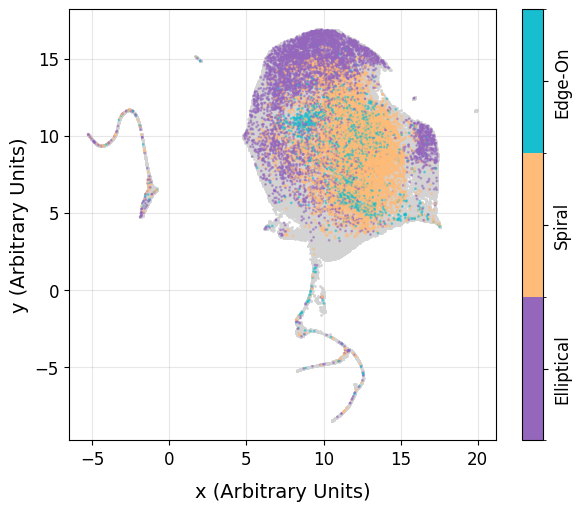

In [30]:
mask = pca_features.index.isin(test_subset.index)

# Coloured by Volunteer Label
class_order = ['R', 'S', 'E']
class_to_int = {label: i for i, label in enumerate(class_order)}
type_ints = test_subset['Volunteer_Label'].map(class_to_int)
type_colours = ["#9467bd", "#ffbb78", "#17becf"]
cmap_type = ListedColormap(type_colours)
norm_type = mcolors.BoundaryNorm(np.arange(-0.5, len(class_order) + 0.5, 1), cmap_type.N)

fig, ax = plt.subplots(figsize=(6,5), constrained_layout=True)

ax.set_aspect('equal')
ax.set_axisbelow(True) 
ax.grid(alpha=0.3)

ax.scatter(umap_features[~mask, 0], umap_features[~mask, 1], c='lightgrey', s=1)
sc = ax.scatter(umap_features[mask, 0], umap_features[mask, 1], c=type_ints, cmap=cmap_type, norm=norm_type, s=1, alpha=0.5)

cbar = fig.colorbar(sc, ax=ax, ticks=np.arange(len(class_order)))
cbar.solids.set_alpha(1)
cbar.set_ticklabels(['Elliptical', 'Spiral', 'Edge-On'], rotation=90, va='center') # R S E
cbar.ax.tick_params(labelsize=12)

ax.set_xlabel("x (Arbitrary Units)", fontsize=14, labelpad=10)
ax.set_ylabel("y (Arbitrary Units)", fontsize=14)
ax.tick_params(labelsize=12)

plt.savefig(os.path.join(output_dir, 'UMAP_test_subset.png'))
display(fig)
plt.close(fig)

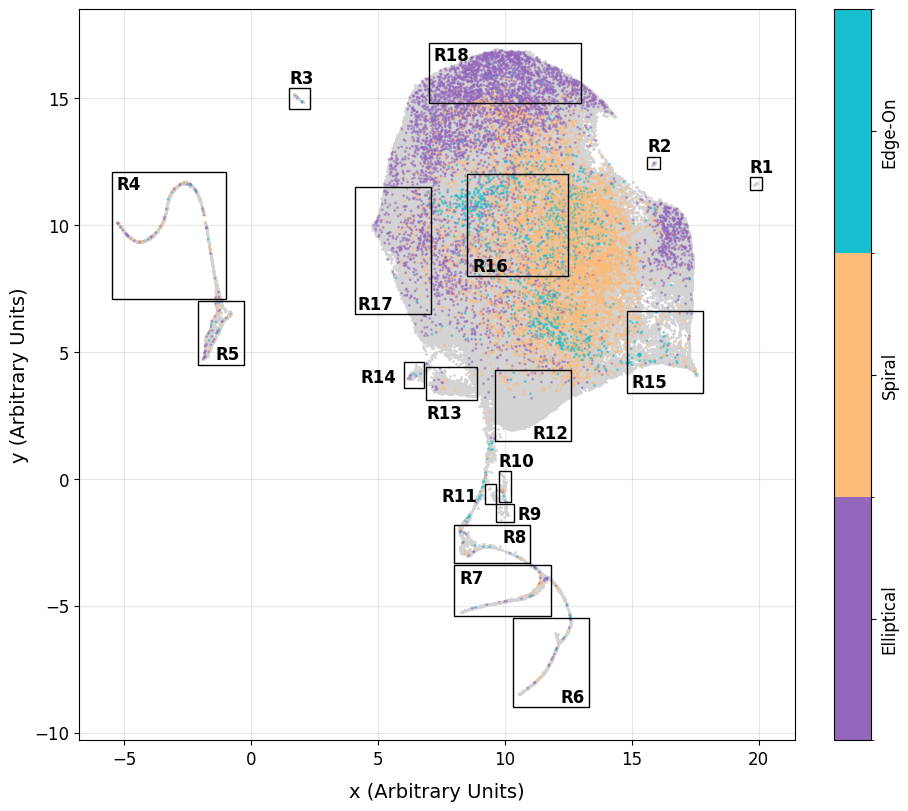

In [31]:
regions = [
    (19.65, 11.4, 0.5, 0.5, 'R1', 19.65, 12.1),
    (15.6, 12.2, 0.5, 0.5, 'R2', 15.6, 12.9),
    (1.5, 14.6, 0.8, 0.8, 'R3', 1.5, 15.6),
    (-5.5, 7.1, 4.5, 5, 'R4', -5.3, 11.4),
    (-2.1, 4.5, 1.8, 2.5, 'R5', -1.4, 4.7),
    (10.3, -9, 3, 3.5, 'R6', 12.2, -8.8),
    (8, -5.4, 3.8, 2, 'R7', 8.2, -4.1),
    (8, -3.3, 3, 1.5, 'R8', 9.9, -2.5),
    (9.65, -1.7, 0.7, 0.7, 'R9', 10.5, -1.6),
    (9.75, -0.9, 0.5, 1.2, 'R10', 9.75, 0.5),
    (9.2, -1, 0.45, 0.8, 'R11', 7.5, -0.9),
    (9.6, 1.5, 3, 2.8, 'R12', 11.1, 1.6),
    (6.9, 3.1, 2, 1.3, 'R13', 6.9, 2.4),
    (6, 3.6, 0.8, 1, 'R14', 4.3, 3.8),
    (14.8, 3.4, 3, 3.2, 'R15', 15, 3.6),
    (8.5, 8, 4, 4, 'R16', 8.7, 8.2),
    (4.1, 6.5, 3, 5, 'R17', 4.2, 6.7),
    (7, 14.8, 6, 2.4, 'R18', 7.2, 16.5)  
]

mask = pca_features.index.isin(test_subset.index)

# Coloured by Volunteer Label
class_order = ['R', 'S', 'E']
class_to_int = {label: i for i, label in enumerate(class_order)}
type_ints = test_subset['Volunteer_Label'].map(class_to_int)
type_colours = ["#9467bd", "#ffbb78", "#17becf"]
cmap_type = ListedColormap(type_colours)
norm_type = mcolors.BoundaryNorm(np.arange(-0.5, len(class_order) + 0.5, 1), cmap_type.N)

fig, ax = plt.subplots(figsize=(9,8), constrained_layout=True)
ax.set_axisbelow(True) 
ax.grid(alpha=0.3)
ax.scatter(umap_features[~mask, 0], umap_features[~mask, 1], c='lightgrey', s=1, label='Unlabelled')
sc = ax.scatter(umap_features[mask, 0], umap_features[mask, 1], c=type_ints, cmap=cmap_type, norm=norm_type, s=1, alpha=0.5)

for i, (x, y, width, height, label, label_x, label_y) in enumerate(regions):
    ax.add_patch(Rectangle((x, y), width, height, edgecolor='black', facecolor='none', linewidth=1))
    ax.annotate(label, (label_x, label_y), fontsize=12, color='black', weight='semibold')

ax.set_xlabel("x (Arbitrary Units)", fontsize=14, labelpad=10)
ax.set_ylabel("y (Arbitrary Units)", fontsize=14)
ax.tick_params(labelsize=12)
ax.set_aspect('equal')

cbar = fig.colorbar(sc, ax=ax, ticks=np.arange(len(class_order)))
cbar.solids.set_alpha(1)
cbar.set_ticklabels(['Elliptical', 'Spiral', 'Edge-On'], rotation=90, va='center') # R S E
cbar.ax.tick_params(labelsize=12)

plt.savefig(os.path.join(output_dir, 'UMAP_regions.png'))
display(fig)
plt.close(fig)

In [ ]:
def violin_plots(ax, question, y_label):
    sns.violinplot(x='Cluster', y=question, data=test_subset,
               ax=ax, density_norm='width', palette='husl', hue='Cluster', cut=0, gridsize=200, common_norm=False, inner=None, legend = False, labelpad=10)
    ax.set_ylabel(y_label)

fig, ax = plt.subplots(5,1, figsize=(10,8), sharex=True, constrained_layout=True)
violin_plots(ax[0], 'smooth-or-featured_featured-or-disk_fraction', 'smooth-or-featured_\nfeatured-or-disk_fraction')
violin_plots(ax[1], 'smooth-or-featured_smooth_fraction', 'smooth-or-featured_\nsmooth_fraction')
violin_plots(ax[2], 'how-rounded_round_fraction', 'how-rounded_\nround_fraction')
violin_plots(ax[3], 'disk-edge-on_yes_fraction', 'disk-edge-on_\nyes_fraction')
violin_plots(ax[4], 'has-spiral-arms_yes_fraction', 'has-spiral-arms_\nyes_fraction')

plt.savefig(os.path.join(output_dir, f'{method}_violins.png'))
display(fig)
plt.close(fig)

### Interactive UMAP (Test Set on Feature Space)

In [ ]:
from IPython.display import display
%matplotlib widget

um_feats = pd.DataFrame(umap_features, index=pca_features.index, columns=['0', '1'])
#um_feats = um_feats[mask]
x = um_feats['0'].values
y = um_feats['1'].values
labels = um_feats.index.to_numpy()
plt.close('all')
fig, ax = plt.subplots(figsize=(8,8))
sc = ax.scatter(x, y, c='k', alpha=0.1, s=1)
ax.grid(alpha=0.3)
clicked = [] # keep track of selected indices

def on_click(event):
    if event.inaxes != ax:
        return
    click_x, click_y = event.xdata, event.ydata
    dist = np.hypot(x - click_x, y - click_y)
    i = np.argmin(dist)

    msg = f"Index: {labels[i]} (x={x[i]}, y={y[i]})"
    clicked.append(labels[i])

    # this makes sure it shows in Jupyter output
    #display(msg)

    # mark and label point on plot
    ax.plot(x[i], y[i], 'ro', markersize=1)
    ax.annotate(labels[i], (x[i], y[i]), textcoords="offset points", xytext=(5,5), fontsize=2, color="red")
    fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()

In [ ]:
plt.close('all')
%matplotlib inline
clicked = np.array(clicked)
random_set = rng.choice(clicked, size=10, replace=False)
filenames_to_find = set(random_set.astype(str) + '.png')

# collect paths of images to display
img_paths = []
for root, dirs, files in os.walk(img_dir):
    for file in files:
        if file in filenames_to_find:
            img_paths.append(os.path.join(root, file))

# display images in a grid
n_cols = 5  # number of columns in the grid
n_rows = (len(img_paths) + n_cols - 1) // n_cols  # compute rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
axes = axes.flatten()  # flatten in case of multiple rows

for ax, img_path in zip(axes, img_paths):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')  # hide axes
    filename = os.path.splitext(os.path.basename(img_path))[0]
    ax.annotate(filename, xy=(0.98, 0.98), xycoords='axes fraction', ha='right', va='top', fontsize=11, color='white')

# hide any unused axes
for ax in axes[len(img_paths):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Cluster Size & Membership vs Accuracy

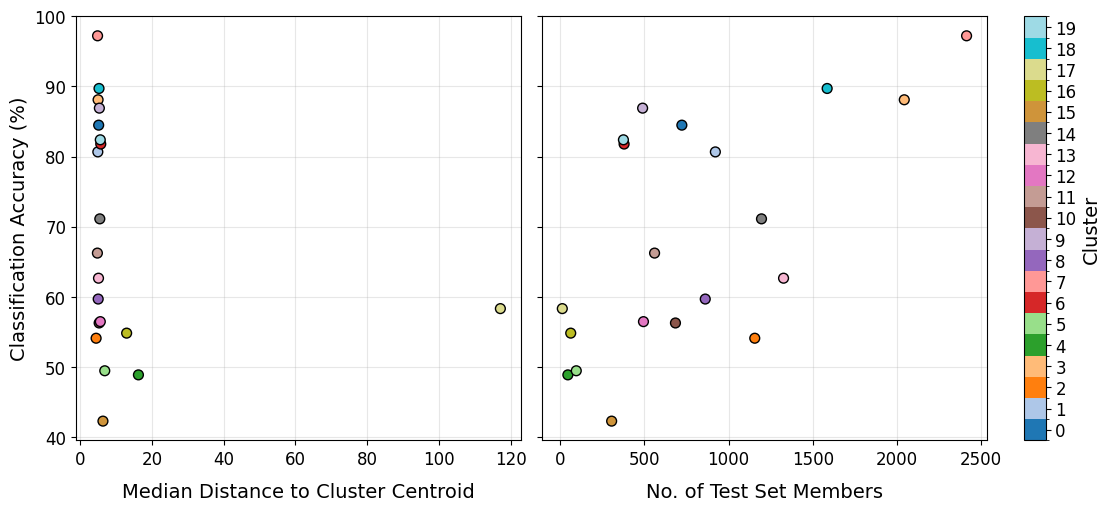

In [37]:
# Find the avg distance of members to their assigned cluster centroid
avg_distance = test_subset.groupby("Cluster")["Assigned_Distance"].median()
cluster_accuracies = pd.Series(cluster_accuracies)
# Find the number of galaxies for each cluster
membership = test_subset.groupby("Cluster").size()
clusters_integers = test_subset["Cluster"].astype(int)

fig, ax = plt.subplots(1, 2, figsize=(11,5), sharey=True, constrained_layout=True)

ax[0].set_axisbelow(True) 
ax[0].grid(alpha=0.3)
ax[1].set_axisbelow(True) 
ax[1].grid(alpha=0.3)

sc = ax[0].scatter(avg_distance, cluster_accuracies*100, c=avg_distance.index, cmap=cmap_cluster, norm=norm_cluster, s=50, edgecolor='black')

ax[0].set_xlabel('Median Distance to Cluster Centroid', fontsize=14, labelpad=10)
ax[0].set_ylabel('Classification Accuracy (%)', fontsize=14)
ax[0].set_ylim(top=100)
ax[0].tick_params(labelsize=12)

ax[1].scatter(membership, cluster_accuracies*100, c=avg_distance.index, cmap=cmap_cluster, norm=norm_cluster, s=50, edgecolor='black')

ax[1].set_xlabel('No. of Test Set Members', fontsize=14, labelpad=10)
ax[1].tick_params(labelsize=12)

cbar = fig.colorbar(sc, ax=ax[1], ticks=np.arange(no_of_clusters))
cbar.solids.set_alpha(1)
cbar.set_label("Cluster", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.savefig(os.path.join(output_dir, f'{method}_size_membership.png'))
display(fig)
plt.close(fig)

In [ ]:
accuracies = results[20][1]['cluster_accuracies']
accuracies = pd.Series(accuracies)
weights = results[20][1]['weights']
# Find the number of galaxies for each cluster
membership = test_subset.groupby("Cluster").size()

fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharey=True, constrained_layout=True)

ax[0].set_axisbelow(True) 
ax[0].grid(alpha=0.3)
ax[1].set_axisbelow(True) 
ax[1].grid(alpha=0.3)

sc = ax[0].scatter(weights, accuracies*100, c=accuracies.index, cmap=cmap_cluster, norm=norm_cluster, s=50, edgecolor='black')

ax[0].set_xlabel("Cluster Weights", fontsize=14, labelpad=10)
ax[0].set_ylabel("Classification Accuracy (%)", fontsize=14)
ax[0].tick_params(labelsize=12)

ax[1].scatter(membership, accuracies*100, c=accuracies.index, cmap=cmap_cluster, norm=norm_cluster, s=50, edgecolor='black')

ax[1].set_xlabel('No. of Test Set Members', fontsize=14, labelpad=10)
ax[1].tick_params(labelsize=12)

cbar = fig.colorbar(sc, ax=ax[1], ticks=np.arange(no_of_clusters))
cbar.solids.set_alpha(1)
cbar.set_label("Cluster", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.savefig(os.path.join(output_dir, f'{method}_size_membership.png'))
display(fig)
plt.close(fig)